# Single Layer Perceptron — Iris (Setosa vs Versicolor)

## 1. Import Library dan Data

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import files

# Baca File dari Github
url = "https://raw.githubusercontent.com/alissatataa/single-layer-perceptron-iris-dataset/main/train.csv"
train = pd.read_csv(url, header=None, names=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species'])

url = "https://raw.githubusercontent.com/alissatataa/single-layer-perceptron-iris-dataset/main/val.csv"
val = pd.read_csv(url, header=None, names=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species'])

In [27]:
train

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
75,6.0,3.4,4.5,1.6,1
76,6.7,3.1,4.7,1.5,1
77,6.3,2.3,4.4,1.3,1
78,5.6,3.0,4.1,1.3,1


## 2. Bersihkan & siapkan data

In [28]:
train = train.rename(columns={
    'SepalLengthCm': 'X1',
    'SepalWidthCm':  'X2',
    'PetalLengthCm': 'X3',
    'PetalWidthCm':  'X4',
})

train['TARGET'] = train['Species']
train = train[['X1', 'X2', 'X3', 'X4', 'TARGET']].reset_index(drop=True)

print(train.shape)
train.head()

(80, 5)


,X1,X2,X3,X4,TARGET
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [29]:
val = val.rename(columns={
    'SepalLengthCm': 'X1',
    'SepalWidthCm':  'X2',
    'PetalLengthCm': 'X3',
    'PetalWidthCm':  'X4',
})

val['TARGET'] = val['Species']
val = val[['X1', 'X2', 'X3', 'X4', 'TARGET']].reset_index(drop=True)

print(val.shape)
val.head()

(20, 5)


,X1,X2,X3,X4,TARGET
0,5.0,3.5,1.3,0.3,0
1,4.5,2.3,1.3,0.3,0
2,4.4,3.2,1.3,0.2,0
3,5.0,3.5,1.6,0.6,0
4,5.1,3.8,1.9,0.4,0


In [30]:
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)

print('Training  :', len(train), 'baris')
print('Validation:', len(val), 'baris')

Training  : 80 baris
Validation: 20 baris


In [31]:
train

,X1,X2,X3,X4,TARGET
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
75,6.0,3.4,4.5,1.6,1
76,6.7,3.1,4.7,1.5,1
77,6.3,2.3,4.4,1.3,1
78,5.6,3.0,4.1,1.3,1


## 3. Inisialisasi parameter
`bias = teta1 = teta2 = teta3 = teta4 = 0.5`, `learning rate = 0.1`, `5 epoch`.

In [32]:
bias = 0.5
teta = np.array([0.5, 0.5, 0.5, 0.5])   # teta1, teta2, teta3, teta4
lr = 0.1
n_epochs = 5

## 4. Fungsi sigmoid, forward pass, dan update bobot

In [33]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def forward(x, bias, teta):
    z = bias + np.dot(teta, x)     # dot product
    g = sigmoid(z)                 # Sigmoid
    pred = 0 if g < 0.5 else 1     # Prediksi
    return z, g, pred


def train_one_epoch(data, bias, teta, lr, epoch_label, log):
    sse_list = []
    for i, row in data.iterrows():
        x = row[['X1', 'X2', 'X3', 'X4']].values.astype(float)
        target = row['TARGET']

        z, g, pred = forward(x, bias, teta)
        error = abs(g - target)          # kolom "error" -> ABS(g(z)-TARGET)
        sse = error ** 2                 # Sum Square Error
        sse_list.append(sse)

        log.append({
            'epoch': epoch_label, 'no': i + 1,
            'bias': bias, 'teta1': teta[0], 'teta2': teta[1], 'teta3': teta[2], 'teta4': teta[3],
            'z': z, 'g_z': g, 'prediksi': pred,
            'target': target, 'error': error, 'sum_square': sse
        })

        # dbias, dteta -> gradient descent (persis rumus di kolom T..X file Excel)
        dbias = 2 * (g - target) * (1 - g) * g
        dteta = dbias * x
        bias = bias - lr * dbias
        teta = teta - lr * dteta

    rata_loss = np.mean(sse_list)
    return bias, teta, log, rata_loss

## 5. Training

In [34]:
log_train = []
rata_loss_per_epoch = []
weight_snapshots = {}

for e in range(1, n_epochs + 1):
    bias, teta, log_train, rata_loss = train_one_epoch(train, bias, teta, lr, f'Iterasi {e}', log_train)
    weight_snapshots[e] = (bias, teta.copy())
    rata_loss_per_epoch.append(rata_loss)
    print(f'Iterasi {e}: rata-rata loss = {rata_loss:.6f}')

train_result = pd.DataFrame(log_train)
print('\nBias & teta akhir setelah training:')
print('bias =', bias)
print('teta =', teta)

train_result.tail(10)

Iterasi 1: rata-rata loss = 0.449889
Iterasi 2: rata-rata loss = 0.037452
Iterasi 3: rata-rata loss = 0.024372
Iterasi 4: rata-rata loss = 0.017357
Iterasi 5: rata-rata loss = 0.012740

Bias & teta akhir setelah training:
bias = 0.25771974812849663
teta = [-0.24180165 -0.41690349  1.1222139   0.82405866]


,epoch,no,bias,teta1,teta2,teta3,teta4,z,g_z,prediksi,target,error,sum_square
390,Iterasi 5,71,0.255409,-0.254908,-0.422952,1.113048,0.821300,2.971344,0.951263,1,1.0,0.048737,0.002375
391,Iterasi 5,72,0.255861,-0.252422,-0.421867,1.114765,0.821798,2.801485,0.942756,1,1.0,0.057244,0.003277
392,Iterasi 5,73,0.256479,-0.249024,-0.420385,1.117051,0.822415,3.020499,0.953492,1,1.0,0.046508,0.002163
393,Iterasi 5,74,0.256891,-0.246632,-0.419271,1.118660,0.822910,4.666892,0.990686,1,1.0,0.009314,0.000087
394,Iterasi 5,75,0.256909,-0.246529,-0.419224,1.118748,0.822938,3.936752,0.980862,1,1.0,0.019138,0.000366
395,Iterasi 5,76,0.256980,-0.246141,-0.419009,1.119071,0.823046,3.708199,0.976065,1,1.0,0.023935,0.000573
396,Iterasi 5,77,0.257092,-0.245470,-0.418629,1.119574,0.823225,3.811533,0.978364,1,1.0,0.021636,0.000468
397,Iterasi 5,78,0.257184,-0.244856,-0.418345,1.120005,0.823362,3.750790,0.977040,1,1.0,0.022960,0.000527
398,Iterasi 5,79,0.257287,-0.244207,-0.418108,1.120458,0.823496,3.299827,0.964423,1,1.0,0.035577,0.001266
399,Iterasi 5,80,0.257531,-0.242840,-0.417375,1.121459,0.823813,3.435267,0.968789,1,1.0,0.031211,0.000974


## 6. Validasi

In [35]:
def validate_only(data, bias, teta):
    log_val = []
    for e in range(1, n_epochs + 1):
        bias_v, teta_v = weight_snapshots[e]
        teta_v = teta_v.copy()
        bias_v, teta_v, log_val, rata_loss_v = train_one_epoch(data, bias_v, teta_v, lr, f'epoch{e}', log_val)
        print(f'Validasi epoch {e}: rata loss = {rata_loss_v:.6f}')
    return pd.DataFrame(log_val)

val_result = validate_only(val, bias, teta)
val_acc = (val_result['prediksi'] == val_result['target']).mean()
print(f'Akurasi validasi: {val_acc:.2%}')
val_result.head(10)

Validasi epoch 1: rata loss = 0.100124
Validasi epoch 2: rata loss = 0.065138
Validasi epoch 3: rata loss = 0.045832
Validasi epoch 4: rata loss = 0.034639
Validasi epoch 5: rata loss = 0.027801
Akurasi validasi: 94.00%


,epoch,no,bias,teta1,teta2,teta3,teta4,z,g_z,prediksi,target,error,sum_square
0,epoch1,1,0.380336,-0.019133,0.071447,0.524449,0.551140,1.381860,0.799289,1,0.0,0.799289,0.638864
1,epoch1,2,0.354691,-0.147360,-0.018312,0.491110,0.543447,0.450931,0.610861,1,0.0,0.610861,0.373151
2,epoch1,3,0.325649,-0.278047,-0.085108,0.453356,0.534734,-0.473790,0.383720,0,0.0,0.383720,0.147241
3,epoch1,4,0.307501,-0.357899,-0.143182,0.429764,0.531104,-0.976848,0.273518,0,0.0,0.273518,0.074812
4,epoch1,5,0.296631,-0.412249,-0.181227,0.412372,0.524583,-1.501160,0.182253,0,0.0,0.182253,0.033216
5,epoch1,6,0.291199,-0.439954,-0.201870,0.402050,0.522410,-1.706599,0.153605,0,0.0,0.153605,0.023595
6,epoch1,7,0.287205,-0.459126,-0.213852,0.396458,0.521211,-2.128400,0.106367,0,0.0,0.106367,0.011314
7,epoch1,8,0.285182,-0.469438,-0.221536,0.393223,0.520807,-1.928477,0.126919,0,0.0,0.126919,0.016108
8,epoch1,9,0.282370,-0.482377,-0.230537,0.389285,0.520244,-2.439242,0.080229,0,0.0,0.080229,0.006437
9,epoch1,10,0.281186,-0.488653,-0.234918,0.387509,0.520008,-2.290795,0.091888,0,0.0,0.091888,0.008443


## 7. Grafik (seperti tab `Chart Train` & `Chart Val`)

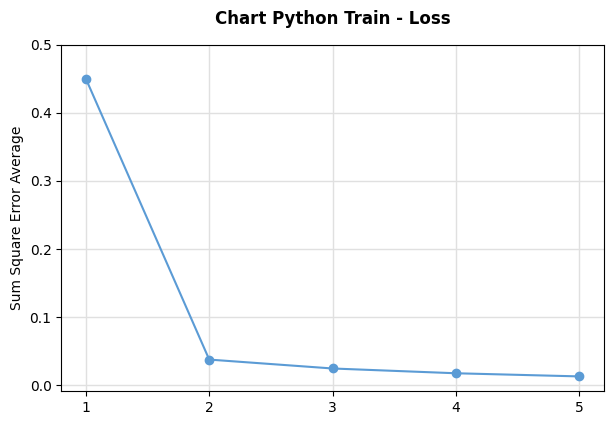

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

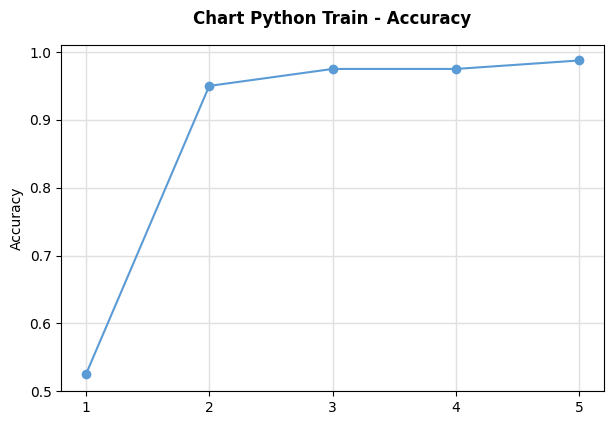

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

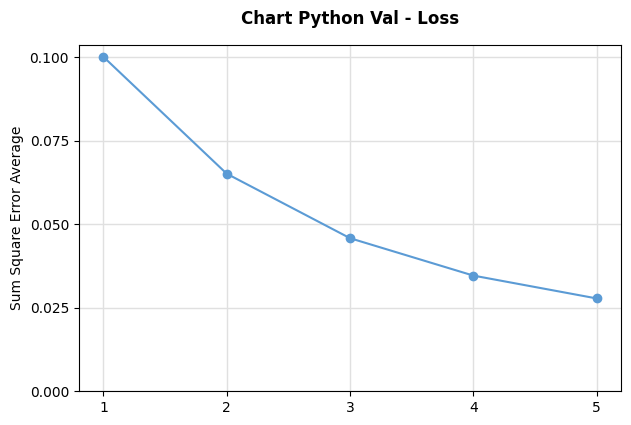

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

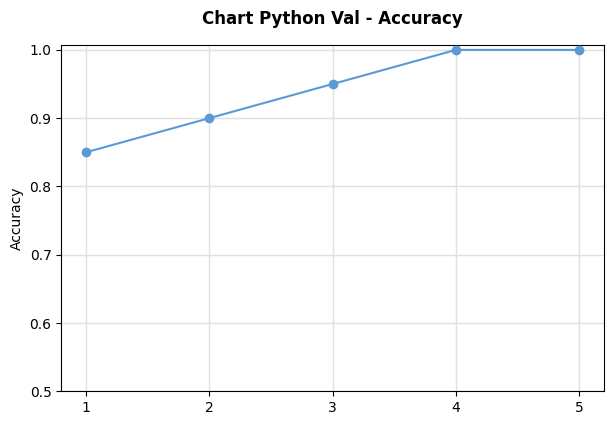

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
def epoch_stats(result_df):
    d = result_df.copy()
    d['correct'] = (d['prediksi'] == d['target']).astype(int)
    return d.groupby('epoch', sort=False).agg(
        loss=('sum_square', 'mean'),
        accuracy=('correct', 'mean')
    ).reset_index()

train_stats = epoch_stats(train_result)
val_stats = epoch_stats(val_result)

folder_path = 'grafik_spreadsheet'
os.makedirs(folder_path, exist_ok=True)

def plot_metric(values, title, ylabel, yticks_range, filename):
    epochs = range(1, len(values) + 1)
    plt.figure(figsize=(7, 4.5))

    plt.grid(True, color='#E0E0E0', linestyle='-', linewidth=1, zorder=1)

    plt.plot(epochs, values, marker='o', color='#5B9BD5', zorder=3)

    plt.title(title, fontweight='bold', pad=15)
    plt.ylabel(ylabel)
    plt.xticks(list(epochs))
    plt.yticks(yticks_range)

    save_path = os.path.join(folder_path, filename)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

    files.download(save_path)

plot_metric(
    train_stats['loss'].tolist(),
    'Chart Python Train - Loss',
    'Sum Square Error Average',
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'train_loss.png'
)

plot_metric(
    train_stats['accuracy'].tolist(),
    'Chart Python Train - Accuracy',
    'Accuracy',
    [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'train_accuracy.png'
)

plot_metric(
    val_stats['loss'].tolist(),
    'Chart Python Val - Loss',
    'Sum Square Error Average',
    [0.0, 0.025, 0.050, 0.075, 0.100],
    'val_loss.png'
)

plot_metric(
    val_stats['accuracy'].tolist(),
    'Chart Python Val - Accuracy',
    'Accuracy',
    [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'val_accuracy.png'
)